<a href="https://colab.research.google.com/github/kuruvajayanth12/Generative-AI/blob/main/GENAI_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [7]:
(x_train,_),(x_test,_)=keras.datasets.fashion_mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_train=np.expand_dims(x_train,-1)

latent_dim=2

In [8]:
inp=keras.Input(shape=(28,28,1))
x=layers.Flatten()(inp)
x=layers.Dense(128,activation="relu")(x)
z_mean=layers.Dense(latent_dim)(x)
z_log_var=layers.Dense(latent_dim)(x)

class Sampling(layers.Layer):
    def call(self,inputs):
        mean,log_var=inputs
        e=tf.random.normal(tf.shape(mean))
        return mean+tf.exp(0.5*log_var)*e

z=Sampling()([z_mean,z_log_var])

In [9]:
d_in=keras.Input(shape=(latent_dim,))
x=layers.Dense(128,activation="relu")(d_in)
x=layers.Dense(784,activation="sigmoid")(x)
d_out=layers.Reshape((28,28,1))(x)
decoder=keras.Model(d_in,d_out)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3904
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3455
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3373
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3338
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3318
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3303
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3291
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3282
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3274
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


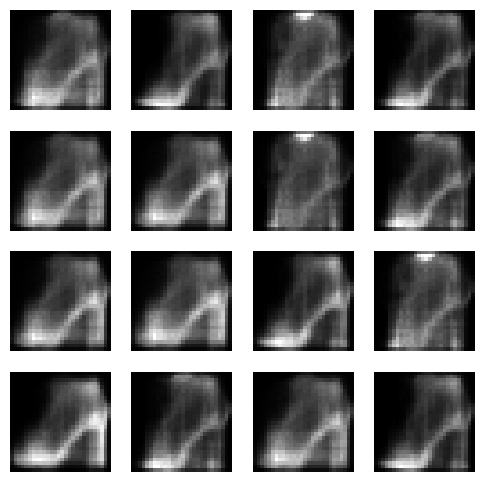

In [10]:
vae=keras.Model(inp,decoder(z))
vae.compile(optimizer="adam",loss="binary_crossentropy")
vae.fit(x_train,x_train,epochs=10,batch_size=128)

# Generate images
z_sample=np.random.normal(0,1,(16,latent_dim))
generated=decoder.predict(z_sample)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated[i].squeeze(),cmap="gray")
    plt.axis("off")
plt.show()